<a href="https://colab.research.google.com/github/NMH1203/DL2026-13-18/blob/main/Notebooks/NDN/Exdark_yolo_clahe_bilateral.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
%pip install -q opencv-python-headless tqdm pyyaml

In [ ]:
from pathlib import Path
import subprocess

REPO_DIR = Path(
    "/content/Dataset"
)

if not REPO_DIR.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "--depth", "1",
            "https://github.com/NMH1203/Low-Light-Image-Enhancement-and-Downstream-Recognition.git",
            str(REPO_DIR),
        ],
        check=True,
    )

print("Repository:", REPO_DIR)

Repository: /content/Dataset


In [ ]:
"""CLAHE + bilateral-filter enhancement for the ExDark dataset."""

import cv2
import numpy as np


def enhance_clahe_bilateral(image_bgr: np.ndarray) -> np.ndarray:
    """Increase local luminance contrast, then denoise while preserving edges."""
    if image_bgr is None or image_bgr.size == 0:
        raise ValueError("Input image is empty.")

    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    luminance, channel_a, channel_b = cv2.split(lab)

    luminance = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8),
    ).apply(luminance)

    enhanced = cv2.cvtColor(
        cv2.merge((luminance, channel_a, channel_b)),
        cv2.COLOR_LAB2BGR,
    )

    return cv2.bilateralFilter(
        enhanced,
        d=7,
        sigmaColor=50.0,
        sigmaSpace=50.0,
    )

In [ ]:
from pathlib import Path

# Dataset lấy từ GitHub
SOURCE_DATASET = (
    REPO_DIR
    / "Dataset"
    / "exdark_yolo_dark"
)

# Dataset CLAHE mới được lưu thẳng vào Google Drive
OUTPUT_DATASET = Path(
    "/content/drive/MyDrive/Project18_Datasets/exdark_yolo_clahe_bilateral"
)

SPLITS = ["train", "valid", "test"]

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
    ".tif",
    ".tiff",
}

assert SOURCE_DATASET.exists(), (
    f"Không tìm thấy dataset: {SOURCE_DATASET}"
)

print("Dataset nguồn:", SOURCE_DATASET)
print("Dataset đầu ra:", OUTPUT_DATASET)

Dataset nguồn: /content/Dataset/Dataset/exdark_yolo_dark
Dataset đầu ra: /content/drive/MyDrive/Project18_Datasets/exdark_yolo_clahe_bilateral


In [ ]:
import cv2
import shutil

from tqdm.auto import tqdm

total_processed = 0
total_skipped = 0

for split in SPLITS:
    source_images_dir = SOURCE_DATASET / split / "images"
    source_labels_dir = SOURCE_DATASET / split / "labels"

    output_images_dir = OUTPUT_DATASET / split / "images"
    output_labels_dir = OUTPUT_DATASET / split / "labels"

    output_images_dir.mkdir(parents=True, exist_ok=True)
    output_labels_dir.mkdir(parents=True, exist_ok=True)

    image_paths = sorted(
        path
        for path in source_images_dir.iterdir()
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    )

    label_paths = sorted(source_labels_dir.glob("*.txt"))

    print(
        f"{split}: {len(image_paths)} ảnh, "
        f"{len(label_paths)} labels"
    )

    # Sao chép nguyên nhãn YOLO
    # CLAHE không resize hoặc crop nên bounding box không thay đổi
    for label_path in label_paths:
        shutil.copy2(
            label_path,
            output_labels_dir / label_path.name,
        )

    # Xử lý tuần tự
    for image_path in tqdm(
        image_paths,
        desc=f"CLAHE {split}",
    ):
        # Hiền Anh lưu ảnh tăng cường dưới dạng PNG
        output_path = (
            output_images_dir
            / f"{image_path.stem}.png"
        )

        # Cho phép tiếp tục nếu Colab bị ngắt giữa chừng
        if output_path.exists() and output_path.stat().st_size > 0:
            total_skipped += 1
            continue

        image_bgr = cv2.imread(
            str(image_path),
            cv2.IMREAD_COLOR,
        )

        if image_bgr is None:
            raise ValueError(
                f"Không đọc được ảnh: {image_path}"
            )

        original_shape = image_bgr.shape

        enhanced_bgr = enhance_clahe_bilateral(image_bgr)

        if enhanced_bgr.shape != original_shape:
            raise ValueError(
                f"Kích thước ảnh bị thay đổi: {image_path}"
            )

        success = cv2.imwrite(
            str(output_path),
            enhanced_bgr,
            [cv2.IMWRITE_PNG_COMPRESSION, 3],
        )

        if not success:
            raise IOError(
                f"Không lưu được ảnh: {output_path}"
            )

        total_processed += 1

print("\nHoàn thành xử lý CLAHE")
print("Ảnh mới xử lý:", total_processed)
print("Ảnh đã tồn tại:", total_skipped)

train: 5142 ảnh, 5142 labels


CLAHE train:   0%|          | 0/5142 [00:00<?, ?it/s]

valid: 1469 ảnh, 1469 labels


CLAHE valid:   0%|          | 0/1469 [00:00<?, ?it/s]

test: 734 ảnh, 734 labels


CLAHE test:   0%|          | 0/734 [00:00<?, ?it/s]


Hoàn thành xử lý CLAHE
Ảnh mới xử lý: 7345
Ảnh đã tồn tại: 0


In [ ]:
import yaml

source_yaml = SOURCE_DATASET / "data.yaml"
output_yaml = OUTPUT_DATASET / "data.yaml"

with open(source_yaml, "r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

config["path"] = OUTPUT_DATASET.as_posix()
config["train"] = "train/images"
config["val"] = "valid/images"
config["test"] = "test/images"

if "names" in config:
    config["nc"] = len(config["names"])

with open(output_yaml, "w", encoding="utf-8") as file:
    yaml.safe_dump(
        config,
        file,
        sort_keys=False,
        allow_unicode=True,
    )

print("Đã tạo:", output_yaml)
print("\nNội dung data.yaml:")
print(output_yaml.read_text(encoding="utf-8"))

Đã tạo: /content/drive/MyDrive/Project18_Datasets/exdark_yolo_clahe_bilateral/data.yaml

Nội dung data.yaml:
path: /content/drive/MyDrive/Project18_Datasets/exdark_yolo_clahe_bilateral
train: train/images
val: valid/images
test: test/images
names:
  0: Bicycle
  1: Boat
  2: Bottle
  3: Bus
  4: Cat
  5: Cup
  6: Motorbike
  7: People
  8: Table
  9: car
  10: chair
  11: dog
nc: 12



In [ ]:
for split in SPLITS:
    image_count = len(
        list(
            (
                OUTPUT_DATASET
                / split
                / "images"
            ).glob("*.png")
        )
    )

    label_count = len(
        list(
            (
                OUTPUT_DATASET
                / split
                / "labels"
            ).glob("*.txt")
        )
    )

    status = "OK" if image_count == label_count else "LỖI"

    print(
        f"{split:5s}: "
        f"{image_count} ảnh, "
        f"{label_count} labels — {status}"
    )

    assert image_count == label_count

train: 5142 ảnh, 5142 labels — OK
valid: 1469 ảnh, 1469 labels — OK
test : 734 ảnh, 734 labels — OK


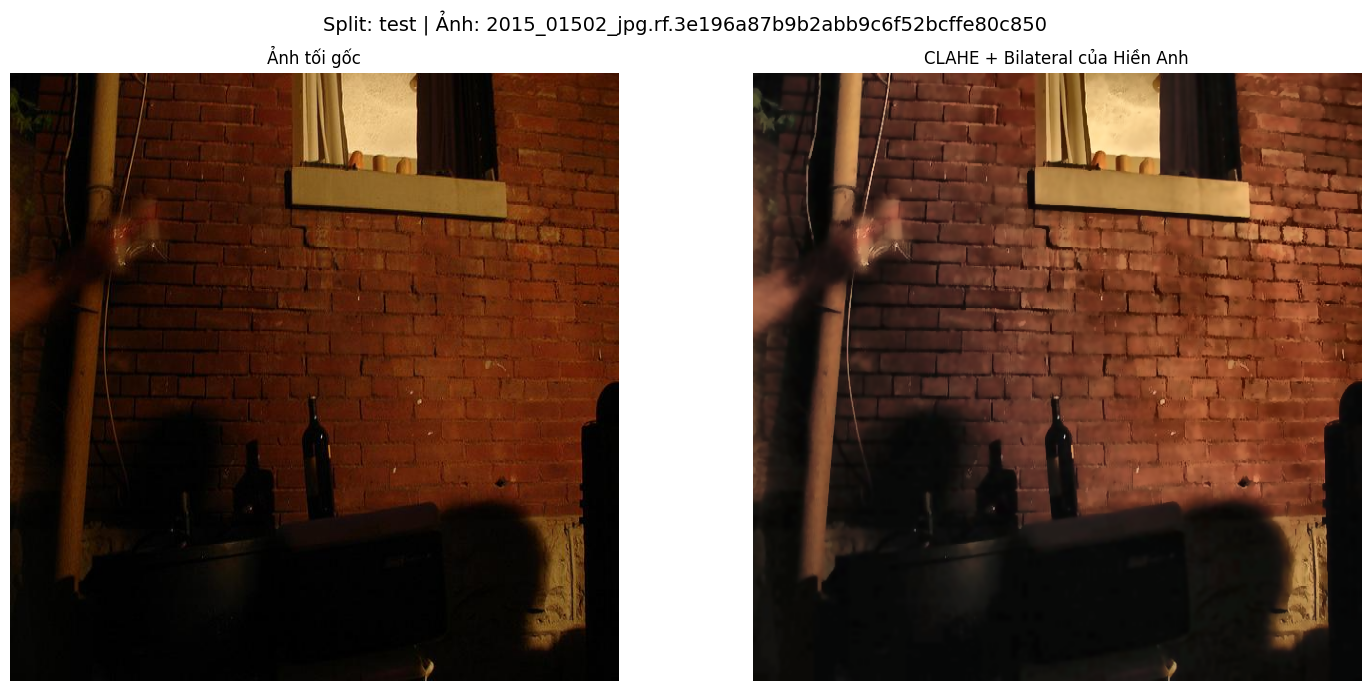

Ảnh gốc: /content/Dataset/Dataset/exdark_yolo_dark/test/images/2015_01502_jpg.rf.3e196a87b9b2abb9c6f52bcffe80c850.jpg
Ảnh CLAHE: /content/drive/MyDrive/Project18_Datasets/exdark_yolo_clahe_bilateral/test/images/2015_01502_jpg.rf.3e196a87b9b2abb9c6f52bcffe80c850.png


In [ ]:
import random
import cv2
import matplotlib.pyplot as plt

from pathlib import Path

DARK_DATASET = (
    REPO_DIR
    / "Dataset"
    / "exdark_yolo_dark"
)

CLAHE_DATASET = Path(
    "/content/drive/MyDrive/Project18_Datasets/exdark_yolo_clahe_bilateral"
)

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".webp", ".tif", ".tiff",
}

# Chọn ngẫu nhiên split
split = random.choice([
    "train",
    "valid",
    "test",
])

clahe_image_dir = (
    CLAHE_DATASET
    / split
    / "images"
)

clahe_images = [
    path
    for path in clahe_image_dir.iterdir()
    if (
        path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    )
]

if not clahe_images:
    raise FileNotFoundError(
        f"Không tìm thấy ảnh CLAHE trong {clahe_image_dir}"
    )

# Chọn ngẫu nhiên một ảnh CLAHE
clahe_path = random.choice(clahe_images)

# Tìm ảnh gốc có cùng stem
dark_image_dir = (
    DARK_DATASET
    / split
    / "images"
)

dark_candidates = [
    path
    for path in dark_image_dir.iterdir()
    if (
        path.is_file()
        and path.stem == clahe_path.stem
        and path.suffix.lower() in IMAGE_EXTENSIONS
    )
]

if not dark_candidates:
    raise FileNotFoundError(
        f"Không tìm được ảnh gốc của {clahe_path.name}"
    )

dark_path = dark_candidates[0]

# Đọc ảnh
dark_bgr = cv2.imread(str(dark_path))
clahe_bgr = cv2.imread(str(clahe_path))

if dark_bgr is None:
    raise ValueError(f"Không đọc được ảnh gốc: {dark_path}")

if clahe_bgr is None:
    raise ValueError(f"Không đọc được ảnh CLAHE: {clahe_path}")

# OpenCV đọc BGR, matplotlib cần RGB
dark_rgb = cv2.cvtColor(
    dark_bgr,
    cv2.COLOR_BGR2RGB,
)

clahe_rgb = cv2.cvtColor(
    clahe_bgr,
    cv2.COLOR_BGR2RGB,
)

# Hiển thị
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(dark_rgb)
plt.title("Ảnh tối gốc")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(clahe_rgb)
plt.title("CLAHE + Bilateral của Hiền Anh")
plt.axis("off")

plt.suptitle(
    f"Split: {split} | Ảnh: {clahe_path.stem}",
    fontsize=14,
)

plt.tight_layout()
plt.show()

print("Ảnh gốc:", dark_path)
print("Ảnh CLAHE:", clahe_path)

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

CUDA available: True
GPU: Tesla T4


In [ ]:
import os

REPO = "/content/Dataset"
TRAIN_SCRIPT = "/content/Dataset/src/LBN/train_ninh.py"
YOLO_MODEL = "/content/Dataset/yolov8n.pt"

print("========== REPOSITORY ==========")
print("Repo exists:", os.path.isdir(REPO))

print("\n========== TRAIN SCRIPT ==========")
print("train_ninh.py exists:", os.path.isfile(TRAIN_SCRIPT))
print("Path:", TRAIN_SCRIPT)

print("\n========== YOLO MODEL ==========")
print("yolov8n.pt exists:", os.path.isfile(YOLO_MODEL))
print("Path:", YOLO_MODEL)

print("\n========== FILE SIZE ==========")
if os.path.isfile(YOLO_MODEL):
    print(f"yolov8n.pt: {os.path.getsize(YOLO_MODEL) / (1024**2):.2f} MB")

========== REPOSITORY ==========
Repo exists: True

========== TRAIN SCRIPT ==========
train_ninh.py exists: True
Path: /content/Dataset/src/LBN/train_ninh.py

========== YOLO MODEL ==========
yolov8n.pt exists: True
Path: /content/Dataset/yolov8n.pt

========== FILE SIZE ==========
yolov8n.pt: 6.25 MB


In [ ]:
%cd /content/Dataset

!python src/LBN/train_ninh.py train --help

/content/Dataset
usage: train_ninh.py train [-h] --data DATA [--device DEVICE]
                           [--project PROJECT] --name NAME [--batch BATCH]
                           [--imgsz IMGSZ] [--epochs EPOCHS] [--seed SEED]
                           [--hsv-v HSV_V] [--close-mosaic CLOSE_MOSAIC]
                           [--patience PATIENCE]

options:
  -h, --help            show this help message and exit
  --data DATA
  --device DEVICE       auto, cpu, or a single CUDA index such as 0
  --project PROJECT
  --name NAME
  --batch BATCH
  --imgsz IMGSZ
  --epochs EPOCHS
  --seed SEED
  --hsv-v HSV_V
  --close-mosaic CLOSE_MOSAIC
  --patience PATIENCE


In [ ]:
import os
import yaml

DATASET = "/content/drive/MyDrive/Project18_Datasets/exdark_yolo_clahe_bilateral"
DATA_YAML = os.path.join(DATASET, "data.yaml")

print("========== DATASET ==========")
print("Dataset exists:", os.path.isdir(DATASET))
print("data.yaml exists:", os.path.isfile(DATA_YAML))

with open(DATA_YAML, "r") as f:
    data = yaml.safe_load(f)

print("\n========== DATA.YAML ==========")
print(yaml.dump(data, sort_keys=False))

print("========== FILE COUNTS ==========")

for split in ["train", "valid", "test"]:
    image_dir = os.path.join(DATASET, split, "images")
    label_dir = os.path.join(DATASET, split, "labels")

    images = [
        f for f in os.listdir(image_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]

    labels = [
        f for f in os.listdir(label_dir)
        if f.lower().endswith(".txt")
    ]

    image_stems = {os.path.splitext(f)[0] for f in images}
    label_stems = {os.path.splitext(f)[0] for f in labels}

    missing_labels = image_stems - label_stems
    missing_images = label_stems - image_stems

    print(f"\n{split.upper()}")
    print("Images :", len(images))
    print("Labels :", len(labels))
    print("Missing labels:", len(missing_labels))
    print("Missing images:", len(missing_images))

========== DATASET ==========
Dataset exists: True
data.yaml exists: True

========== DATA.YAML ==========
path: /content/drive/MyDrive/Project18_Datasets/exdark_yolo_clahe_bilateral
train: train/images
val: valid/images
test: test/images
names:
  0: Bicycle
  1: Boat
  2: Bottle
  3: Bus
  4: Cat
  5: Cup
  6: Motorbike
  7: People
  8: Table
  9: car
  10: chair
  11: dog
nc: 12

========== FILE COUNTS ==========

TRAIN
Images : 5142
Labels : 5142
Missing labels: 0
Missing images: 0

VALID
Images : 1469
Labels : 1469
Missing labels: 0
Missing images: 0

TEST
Images : 734
Labels : 734
Missing labels: 0
Missing images: 0


In [ ]:
import os

RESULT_DIR = "/content/drive/MyDrive/Project18_Results/clahe_bilateral_yolov8n"

print("Result directory exists:", os.path.isdir(RESULT_DIR))

if os.path.isdir(RESULT_DIR):
    print("\nExisting files/folders:")
    for item in os.listdir(RESULT_DIR):
        print(" -", item)

Result directory exists: False


In [ ]:
!pip install -U ultralytics

import torch
import ultralytics

print("\n========== ENVIRONMENT ==========")
print("Ultralytics version:", ultralytics.__version__)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 10.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.

========== ENVIRONMENT ==========
Ultralytics version: 8.4.173
PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4
CUDA version: 13.0


In [ ]:
%cd /content/Dataset

!python src/LBN/train_ninh.py train \
    --data /content/drive/MyDrive/Project18_Datasets/exdark_yolo_clahe_bilateral/data.yaml \
    --device 0 \
    --project /content/drive/MyDrive/Project18_Results_Exdark_yolo_clahe_bilateral \
    --name clahe_bilateral_yolov8n \
    --epochs 40 \
    --batch 16 \
    --imgsz 640 \
    --seed 42 \
    --patience 15

/content/Dataset
Device=0, CUDA available=True
Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Project18_Datasets/exdark_yolo_clahe_bilateral/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.9

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

CUDA available: False
GPU: None
